# Loading the Model

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

In [2]:
# Path to your saved model folder (not directly the .pb file)
model_path = "../TOMATOES/modelsFT/2"
your_model = tf.keras.models.load_model(model_path)

In [3]:
# Prediction function
def predict(model, img, class_names):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch dimension
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

# Running the prediction

1/1 [==============================] - 0s 66ms/step


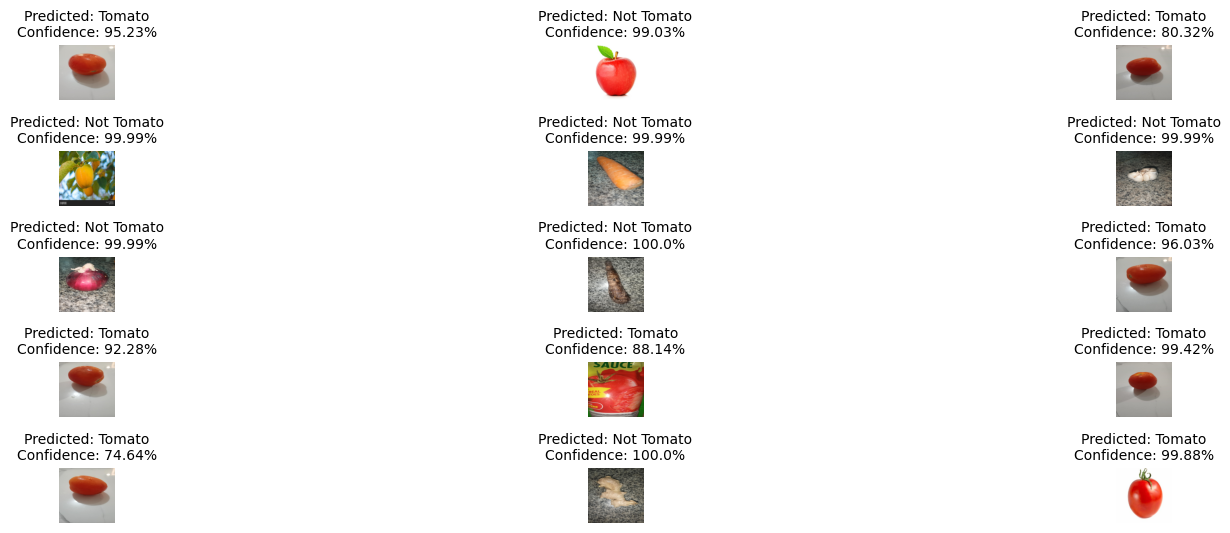

In [18]:
# Class names for predictions
class_names = ['Not Tomato', 'Tomato'] #Replace with actual classnames in order according to your training

# Directory containing test images
img_dir = './TEST' #Replace with your actual directory
image_files = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

plt.figure(figsize=(16, 16))

for i, img_path in enumerate(image_files[0:]):  # Show first 9 images
    img = image.load_img(img_path, target_size=(299, 299))
    ax = plt.subplot(len(image_files), 3, i + 1)
    plt.imshow(img)

    predicted_class, confidence = predict(your_model, img, class_names)
    
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence}%", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()